In [2]:
import pandas as pd
pd.set_option("display.max_columns", None)

import seaborn as sns
sns.set_theme(style = "darkgrid")

import matplotlib.pyplot as plt
import numpy as np

In [3]:
telco = pd.read_csv("../data/Telco-Customer-Churn.csv")

In [4]:
telco.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
rows = telco.shape[0]
columns = telco.shape[1]

print(f"rows: {rows}")
print(f"columns: {columns}\n")
print(f"total duplicates {telco.duplicated().sum()}\n")

for column in telco.columns:
    print(f"#### {column} ####")
    print(f"data type: {telco[column].dtype}")
    print(f"number of unique values: {telco[column].nunique()}")
    if column not in ["TotalCharges", "MonthlyCharges", "customerID", "tenure"]:
        print(f"unique values: {telco[column].unique()}")
    print(f"missing values {telco[column].isna().sum()}\n")

rows: 7043
columns: 21

total duplicates 0

#### customerID ####
data type: str
number of unique values: 7043
missing values 0

#### gender ####
data type: str
number of unique values: 2
unique values: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
missing values 0

#### SeniorCitizen ####
data type: int64
number of unique values: 2
unique values: [0 1]
missing values 0

#### Partner ####
data type: str
number of unique values: 2
unique values: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
missing values 0

#### Dependents ####
data type: str
number of unique values: 2
unique values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
missing values 0

#### tenure ####
data type: int64
number of unique values: 73
missing values 0

#### PhoneService ####
data type: str
number of unique values: 2
unique values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
missing values 0

#### MultipleLines ####
data type: str
number of unique values: 3
unique values: <StringArray>
['No p

All columns appear to be clean apart from `TotalCharges`, which is labelled as `str` rather than `float`. As the five viewed values are `float`, it is likely that some entries elsewhere are non-numeric, causing pandas to store the column as a `str`. 

In [6]:
non_float = pd.to_numeric(
    telco["TotalCharges"], 
    errors = "coerce"
).isna()

print(len(telco[non_float]))
telco[non_float]

11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


There are a total of $11$ rows which contain missing values. In every instance, the `tenure` value is $0$, indicating that these are new customers, meaning there are no `TotalCharges`. In this case, it is appropriate to fill these missing values in as $0.0$, and to convert the column into a numeric data type. 

In [7]:
telco.loc[non_float, "TotalCharges"] = "0.0"
telco["TotalCharges"] = telco["TotalCharges"].astype(float)

## EDA

We start of by mapping the `SeniorCitizen` values to `Yes` and `No` as this will be treated as a categorical column. We remove `customerID` since it is not useful for modelling, and finally we split the data between categorical and numerical data types. 

In [8]:
senior_citizen_map = {
    0: "No", 
    1: "Yes"
}

telco["SeniorCitizen"] = telco["SeniorCitizen"].map(senior_citizen_map)
telco = telco.drop(columns = ["customerID"])

categorical = telco.select_dtypes("str")
numerical = telco.select_dtypes(["float64", "int64"])
numerical["Churn"] = telco["Churn"]

### Numerical

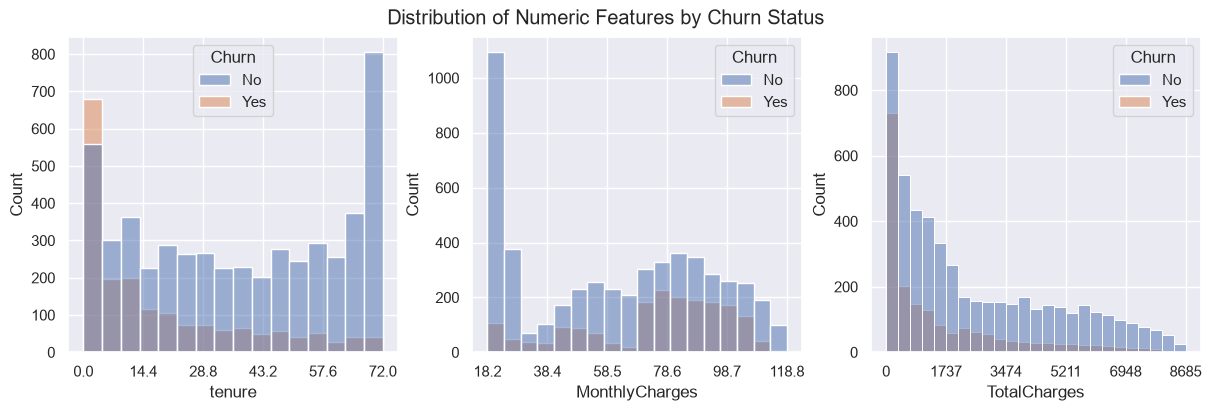

In [9]:
columns = numerical.drop(columns = ["Churn"]).columns.tolist()

fig, axes = plt.subplots(
    nrows = 1, 
    ncols = 3, 
    figsize = (12, 4), 
    constrained_layout = True
)

axes = axes.flatten()
fig.suptitle("Distribution of Numeric Features by Churn Status")

for ax, column in zip(axes, columns):
    sns.histplot(
        data = numerical, 
        x = column, 
        hue = "Churn",
        ax = ax
    )

    x_min = numerical[column].min()
    x_max = numerical[column].max()
    ax.set_xticks(
        np.linspace(
            start = x_min, 
            stop = x_max, 
            num = 6
        )
    )

plt.show()

- Based on the `tenure` distributions, most customers who churn do so within the first 14 months. Customers who remain beyond this point are more likely to be retained. This suggests that customer retention spend should be focused on newer customers, as they are at the highest risk of churning. 

- Based on the `MonthlyCharges` distributions, there is no single price at which churn is concentrated. However, churn appears to be more common among customers paying around 70-110 per month. Retained customers have a similar distribution, but with a large cluster at the lowest price range. 

- The `TotalCharges` distributions reflect both `tenure` and `MonthlyCharges` distributions, as a customer's total spend accumulates over their lifetime. Most customers who churn have low total charges, while retained customers are distributed across a wider range of total charges. 

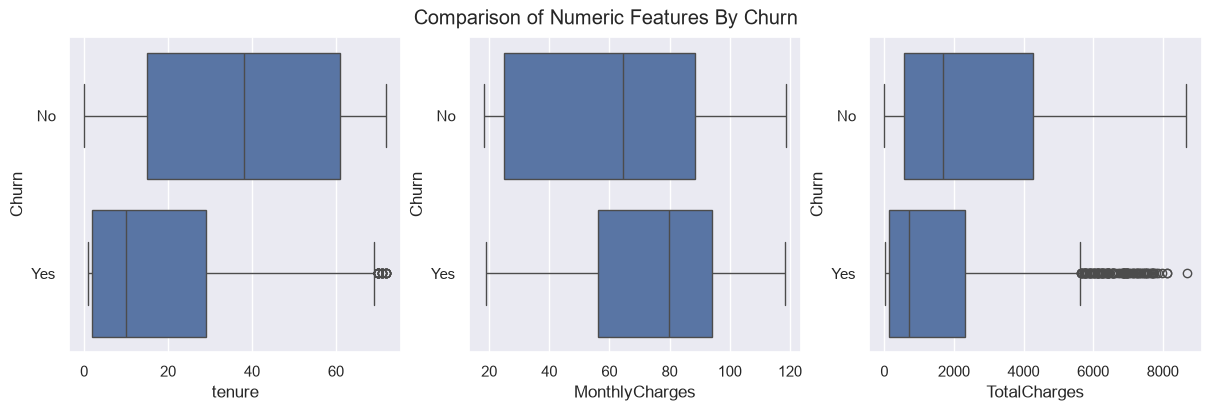

In [10]:
columns = numerical.drop(columns = ["Churn"]).columns.tolist()

fig, axes = plt.subplots(
    nrows = 1, 
    ncols = 3, 
    figsize = (12, 4), 
    constrained_layout = True
)

axes = axes.flatten()
fig.suptitle("Comparison of Numeric Features By Churn")

for ax, column in zip(axes, columns):
    sns.boxplot(
        data = numerical, 
        x = column, 
        y = "Churn",
        ax = ax
    )

plt.show()

- The `tenure` boxplot confirms that, on average, churned customers have a shorter tenure than retained customers. The median tenure of churned customers is considerably lower, with the majority falling below the lower quartile of retained customers. Although churn is concentrated among newer customers, several high-tenure outliers indicate that long-term customers still churn.  

- The `MonthlyCharges` boxplot shows that churned customers have a higher median monthly charge compared to retained customers. Both groups cover a similar range, approximately 20 to 120, but the distribution differs, aligning with the histogram observations. Churned customers are more concentrated towards the middle of the range, 55 to 95, while retained customers cover a wider distribution from 25 to 90.  

- The `TotalCharges` boxplot shows a clear difference between churned and retained customers. Churned customers have a much lower median, with the majority of values concentrated at 0 to 2200. However, there are several high-charge outliers among churned customers, reinforcing that long-term customers still leave. In contrast, retained customers have a wider distribution with the interquartile range ranging from 700 to 4200. This pattern is expected as customers who remain with the company longer accumulate a higher total charge. 

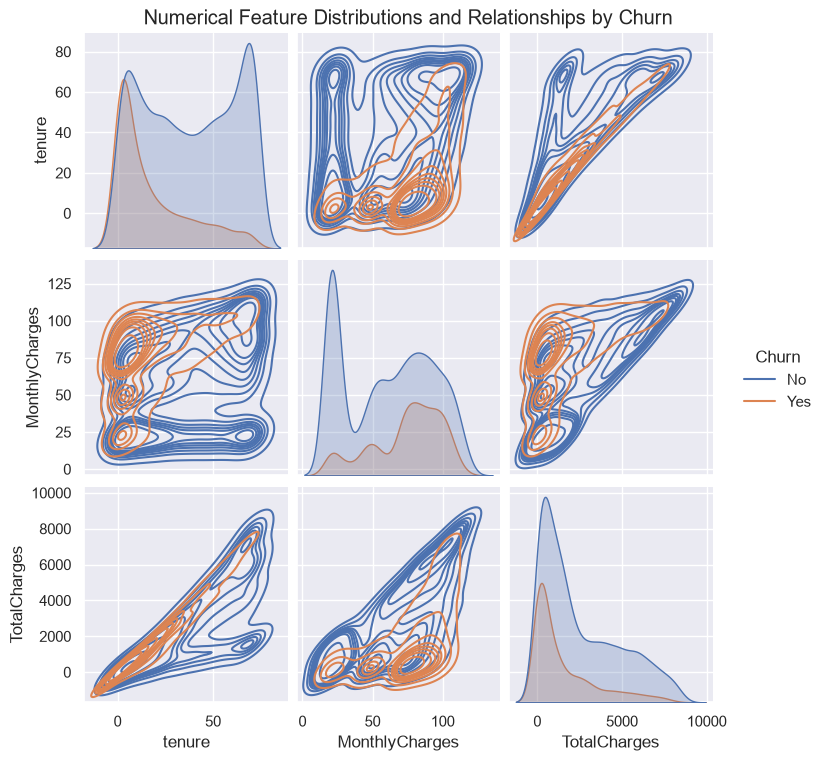

In [11]:
graph = sns.pairplot(
    data = numerical,
    hue = "Churn",
    kind = "kde",
    height = 2.5,
    aspect = 1
)

graph.fig.suptitle(
    "Numerical Feature Distributions and Relationships by Churn",
    y = 1.01
)

plt.show()

- The pairplot highlights several relationships between `tenure`, `MonthlyCharges` and `TotalCharges`. For `tenure` and `MonthlyCharges`, churned customers are concentrated between 0-20 months and monthly charges between 50-100. Retained customers are more widely distributed, with a high concentration of high-tenure customers with low monthly charges. 

- The relationship between `tenure` and `TotalCharges` shows a strong positive correlation. Churned customers are concentrated at a lower tenure and lower total charges, while retained customers have a wider distribution, including many high-tenure customers with low total charges. This aligns well with the observations between `tenure` and `MonthlyCharges`. 

- The relationship between `MonthlyCharges` and `TotalCharges` shows that churned customers are concentrated among lower total charges around 0 to 2000 and high monthly charges around 60 to 100. Retained customers present a wider spread, with total charges increasing with monthly charges. 

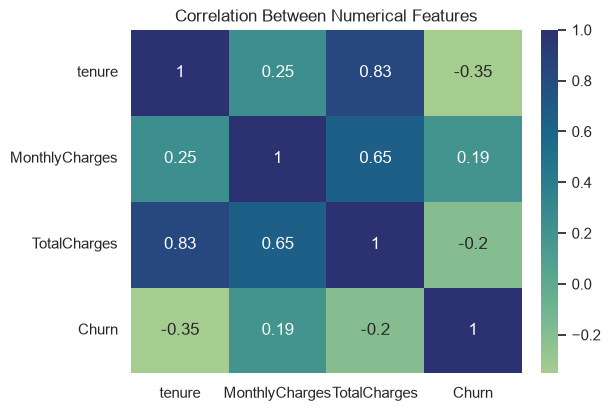

In [12]:
churn_map = {
    "No": 0, 
    "Yes": 1,
    0: 0,
    1: 1
}

numerical_2 = numerical.copy()
numerical_2["Churn"] = numerical_2["Churn"].map(churn_map)

corr = numerical_2.corr()

plt.figure(
    figsize = (6, 4), 
    constrained_layout = True
)

plt.title("Correlation Between Numerical Features")

sns.heatmap(
    data = corr,
    annot = True,
    cmap = "crest"
)

plt.show()

The correlation analysis is consistent with the other findings. `tenure` has the strongest relationship with churn (-0.35), indicating customers with longer tenure are less likely to churn. `MonthlyCharges` and `TotalCharges` show weak correlations. `TotalCharges` is strongly correlated with `tenure` (0.83) and moderately correlated with `MonthlyCharges` (0.25), confirming that it captures information from both features. Although the strong correlation could introduce multicollinearity issues in a logistic regression model, each feature is retained because it captures different aspects of consumer behaviour. Moreover, tree-based models are not affected by this issue. 

### Categorical

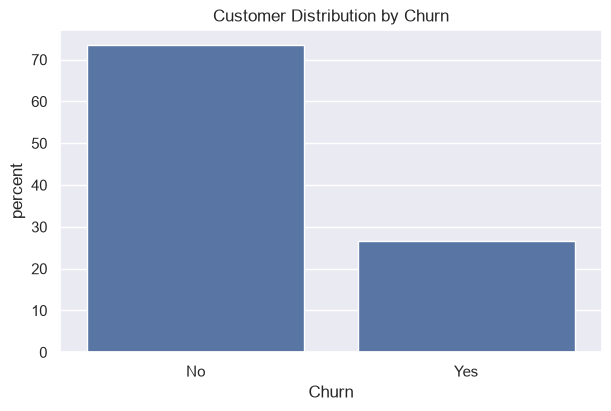

In [13]:
plt.figure(
    figsize = (6, 4), 
    constrained_layout = True
)

plt.title("Customer Distribution by Churn")

sns.countplot(
    data = categorical, 
    x = "Churn",
    stat = "percent"
)

plt.show()

There is roughly a 75:25 split between retained and churned customers, indicating a moderate class imbalance. While the imbalance is not severe, accuracy should not be a primary evaluation metric, since it is possible to achieve 75% accuracy despite failing to identify any customers who churn. Metrics such as precision or recall would provide a better assessment of the model. 

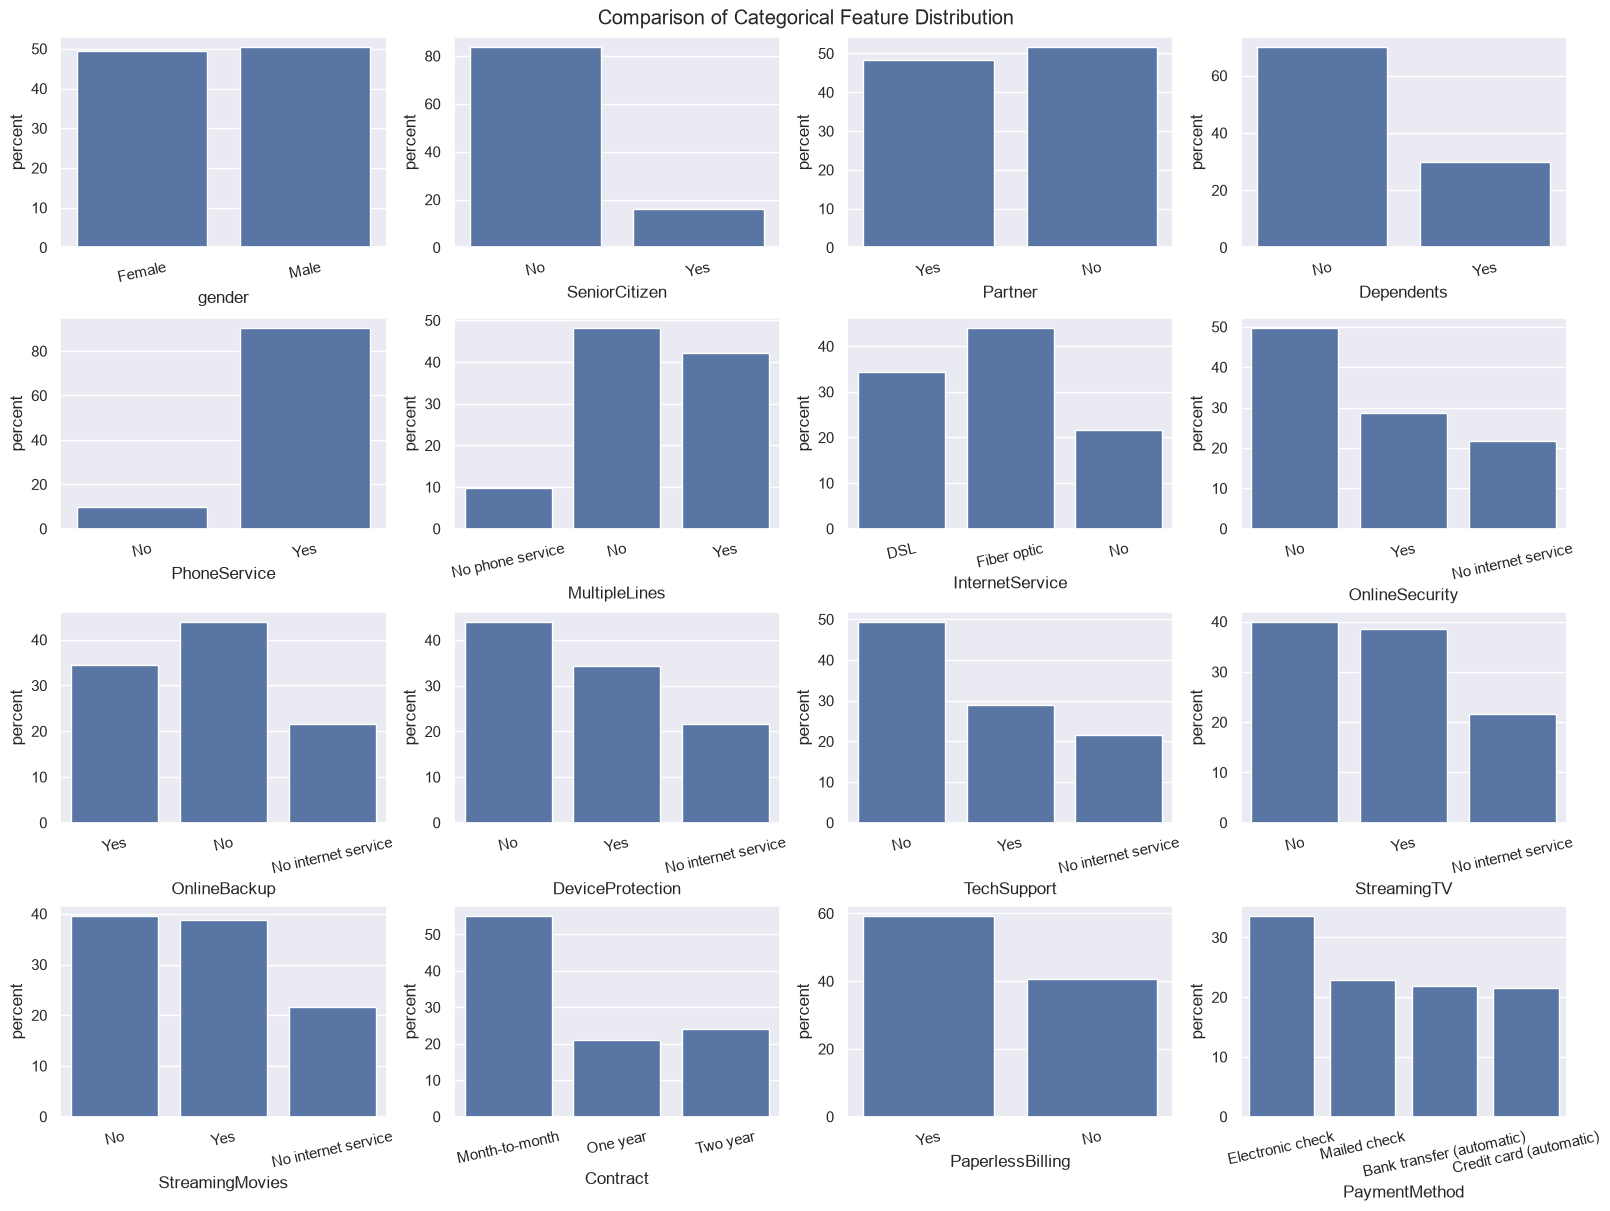

In [14]:
columns = categorical.drop(columns = ["Churn"]).columns.tolist()

fig, axes = plt.subplots(
    nrows = 4, 
    ncols = 4, 
    figsize = (16, 12), 
    constrained_layout = True
)

axes = axes.flatten()
fig.suptitle("Comparison of Categorical Feature Distribution")

for ax, column in zip(axes, columns):
    sns.countplot(
        data = categorical,
        x = column, 
        ax = ax,
        stat = "percent"
    )
    ax.tick_params(axis = "x", rotation = 12.5)

plt.show()

The categorical features are generally evenly distributed across their categories. There are a couple of features that have skewed distributions, mainly `SeniorCitizen` and `PhoneService`, but both contain sufficient observations to provide meaningful information for modelling. Overall, no adjustments are needed, as the imbalances should not negatively impact model performance. 

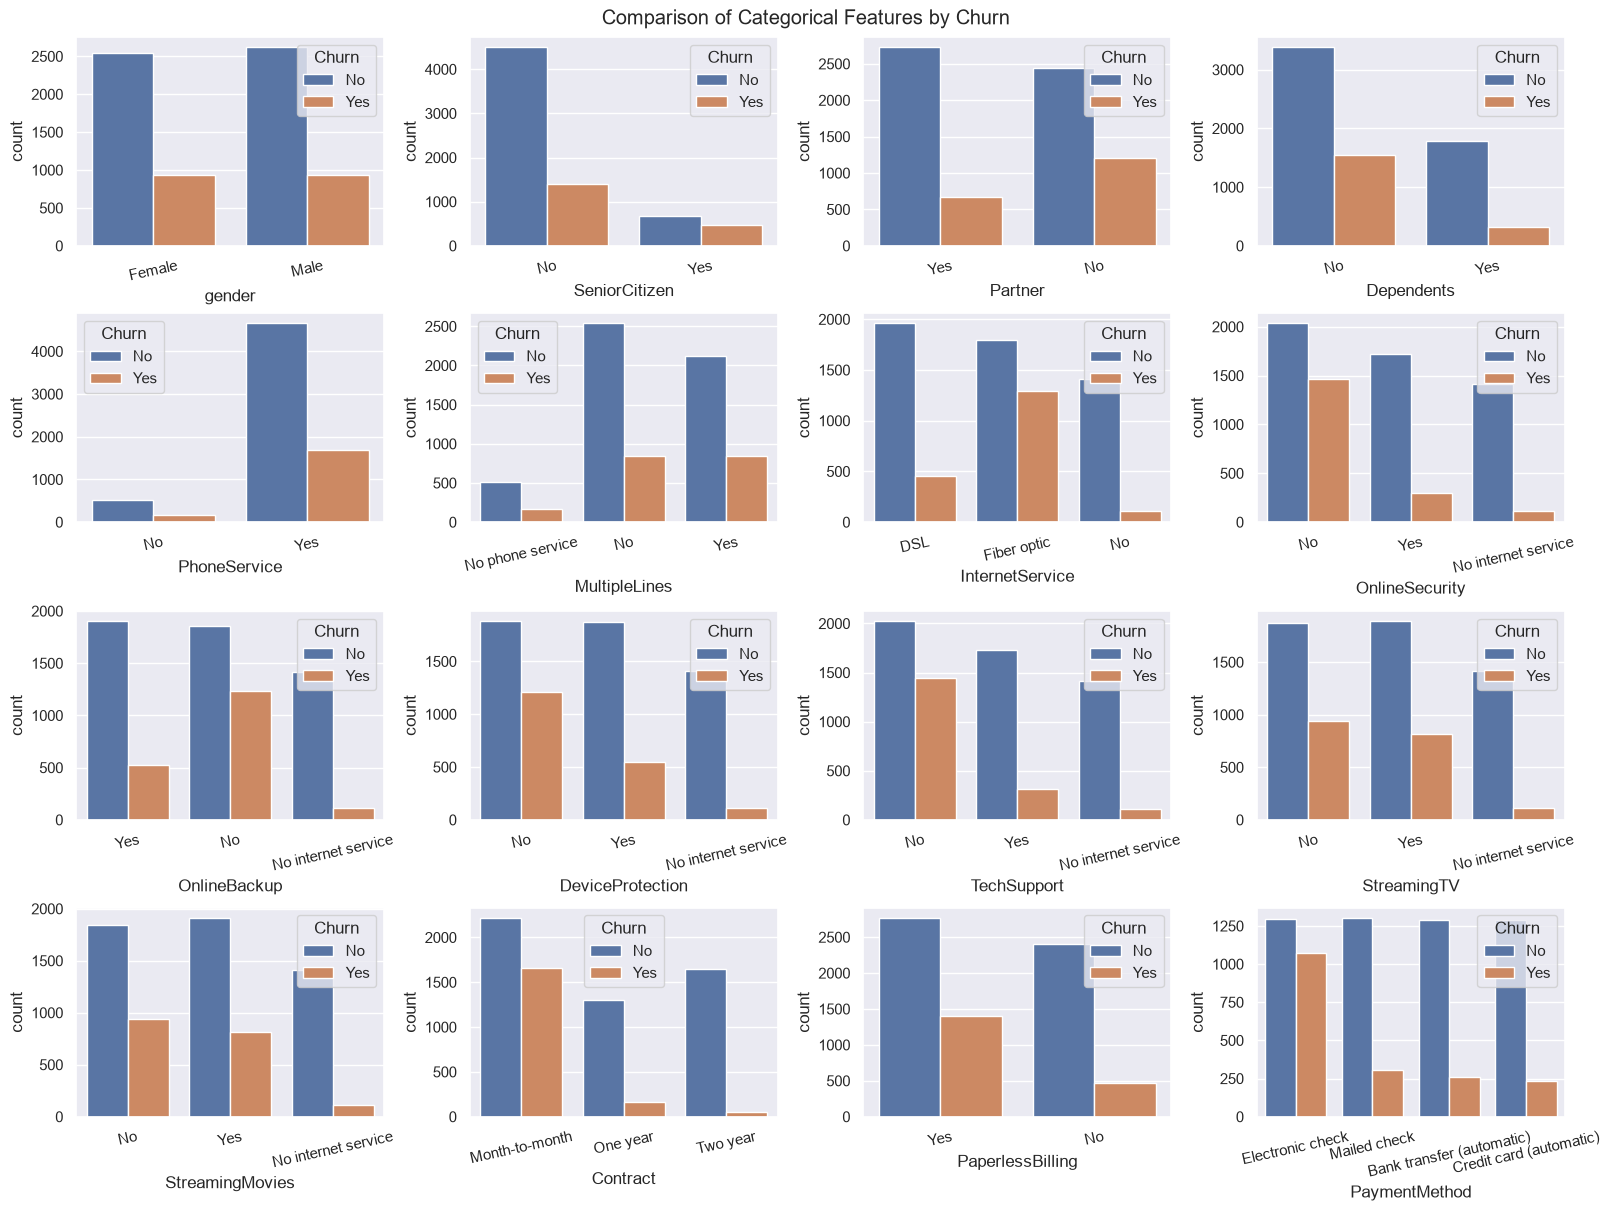

In [15]:
columns = categorical.drop(columns = ["Churn"]).columns.tolist()

fig, axes = plt.subplots(
    nrows = 4, 
    ncols = 4, 
    figsize = (16, 12), 
    constrained_layout = True
)

axes = axes.flatten()
fig.suptitle("Comparison of Categorical Features by Churn")

for ax, column in zip(axes, columns):
    sns.countplot(
        data = categorical,
        x = column, 
        hue = "Churn",
        stat = "count",
        ax = ax
    )
    ax.tick_params(axis = "x", rotation = 12.5)

plt.show()

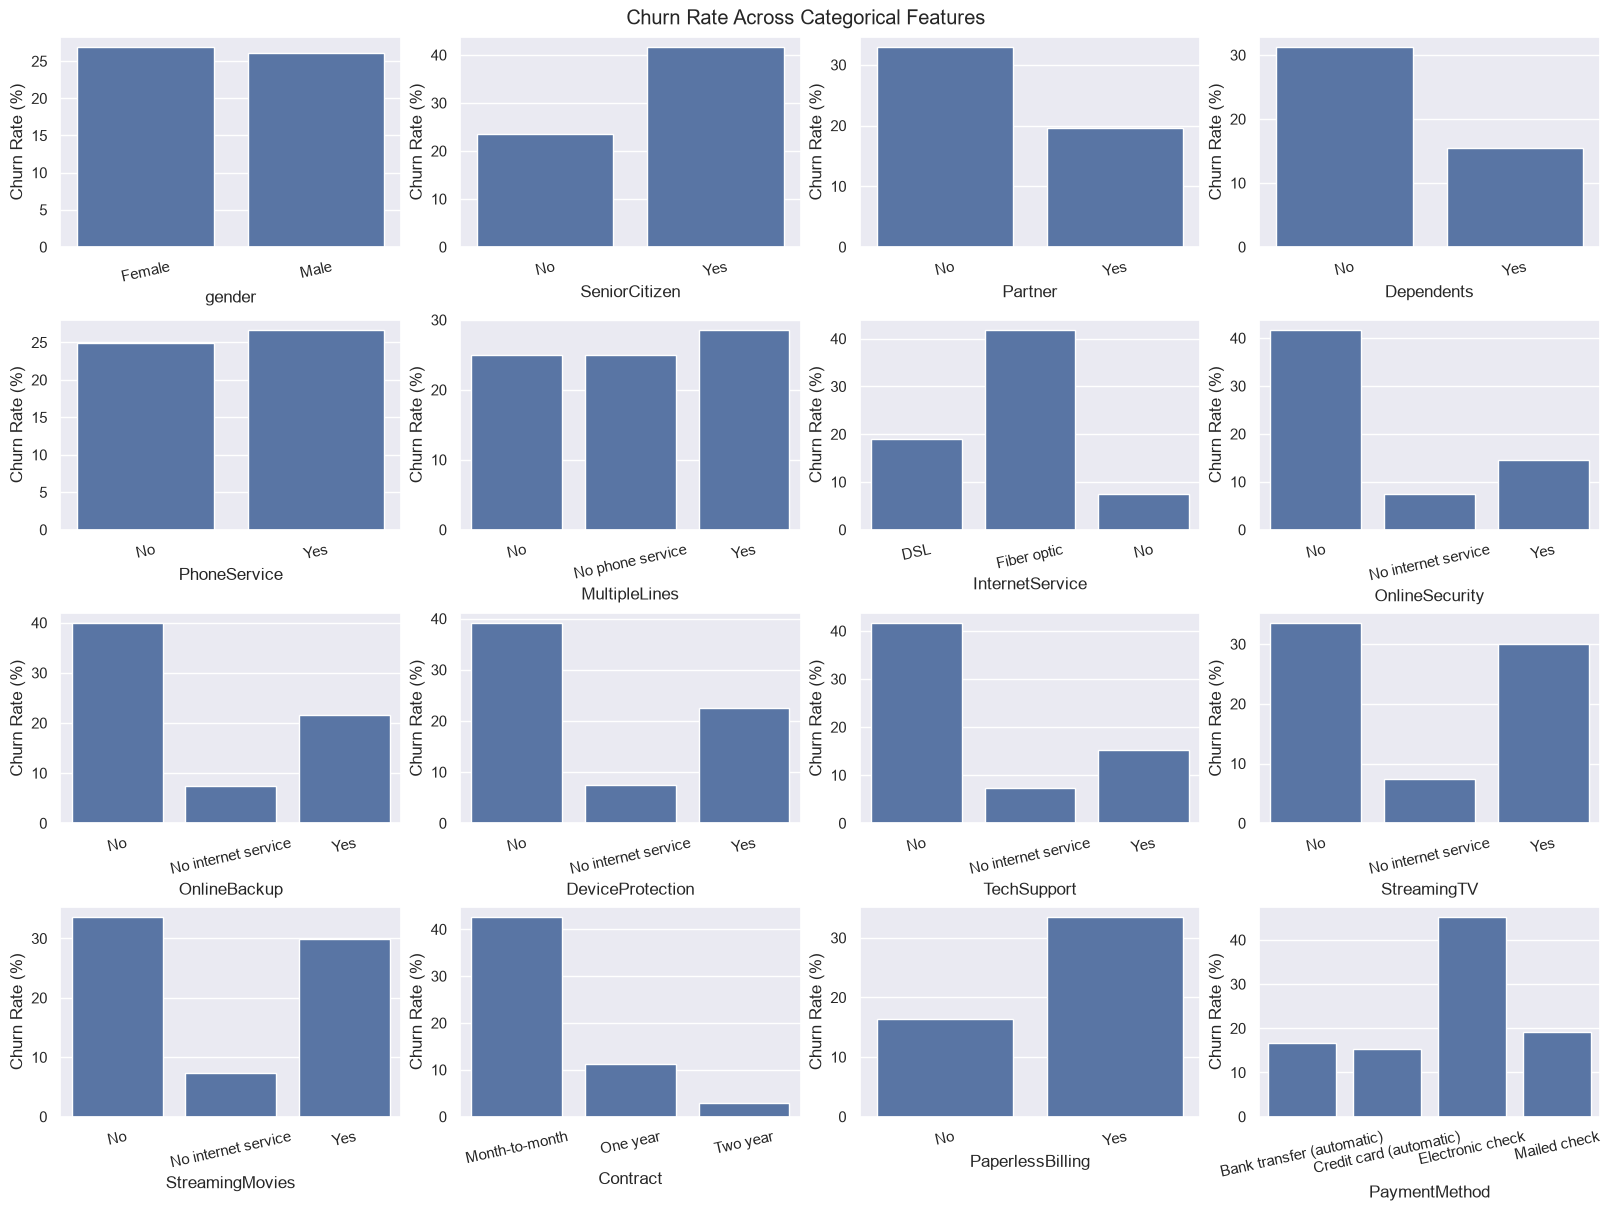

In [16]:
columns = categorical.drop(columns = ["Churn"]).columns.tolist()

fig, axes = plt.subplots(
    nrows = 4, 
    ncols = 4, 
    figsize = (16, 12), 
    constrained_layout = True
)

axes = axes.flatten()
fig.suptitle("Churn Rate Across Categorical Features")

for ax, column in zip(axes, columns):
    churn_rate = categorical.groupby([column, "Churn"]).size().unstack(level = -1).reset_index()
    churn_rate["Churn Rate (%)"] = 100.0 * churn_rate["Yes"] / (churn_rate["Yes"] + churn_rate["No"])

    sns.barplot(
        data = churn_rate,
        x = column,
        y = "Churn Rate (%)",
        ax = ax
    )

    ax.tick_params(axis = "x", rotation = 12.5)

plt.show()

The feature comparison against churn reveals severe variation in churn rates across several categories. Customers that select `No` for `InternetService` have a noticeably low churn rate at 7%, while customers with `Fiber optic` have a 42% churn rate. Customers that do not select additional services, apart from `StreamingMovies`, such as `TechSupport` or `DeviceProtection`, have a high churn rate at 37-42%. The type of `Contract` demonstrates a strong relationship with churn, with `Month-to-month` contracts showing a churn rate of 42%, compared to longer-term contracts, particularly `Two year` contracts at 4%. `PaymentMethod` also shows notable differences, with customers who use `Electronic check` having a churn rate of 44%, compared to other payment methods at 10-20%. Other categories generally range around 20-30%. Overall, the variation across categories suggests that these features may provide valuable predictive information during modelling. 